<a href="https://colab.research.google.com/github/Rogerio-mack/work/blob/main/Bruno_Aneurisma_Tratamento_SCANNERs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U scikit-image[data]

# Questões que surgem com imagens de equipamentos diferentes

**1. Variação de Intensidade e Contraste Inter-Fabricante**

A GE e a Siemens utilizam sequências de pulso, algoritmos de reconstrução e filtros de suavização proprietários diferentes. O "branco" do sangue fluindo ou o "preto" do fundo não têm os mesmos valores numéricos absolutos entre uma máquina GE e uma Siemens. A rede neural será sensível a essas distribuições diferentes.

**2. Razão Sinal-Ruído (SNR) e Contraste (1.5T vs. 3T)**

Equipamentos de 3T (Tesla) possuem o dobro da força de campo dos de 1.5T. Imagens de 3T geralmente têm uma relação sinal-ruído muito maior, vasos mais brilhantes e melhor definição de estruturas finas. Se o modelo treinar majoritariamente com dados de 3T (é o nosso caso, com o Siemens Skyra dominando o dataset), ele pode falhar drasticamente ao tentar detectar aneurismas menores ou menos contrastados nas imagens de 1.5T (GE Optima ou Signa).

**3. Resolução Isotrópica e Espaçamento de Voxel (Voxel Size)**

Mesmo que você mude o tamanho da matriz (ex: redimensionar tudo para $512 \times 512$), o tamanho físico real (em milímetros) que cada pixel/voxel representa pode ser diferente. Assim, um aneurisma de 5mm pode parecer ter tamanhos diferentes em pixels se o Field of View (FOV) ou a espessura do corte da Siemens e da GE variarem.

> Essa última questão não trato aqui, mas entendo que você já está tratando isso (**CONFIMAR**).



# Pré-processamento

Para essas podemos adotar as seguintes estratégias complementares:

**1. Normalização**

Só que no lugar de uma normalização tipo z-score, aplicamos uma técnica de *match-histogram*, aproximando a distribuição das imagens ao um padrão (no caso o do Siemens Skyra).

**2. Data Augmentation com Adição de Ruído**

Simulação de Ruído RICE: O ruído em ressonância magnética segue a distribuição de Rice (e não gaussiano). Adicionar esse ruído ajuda a aproximar os dados de 3T para a realidade de 1.5T.

> **Importante**: Isso não exclui variações de brilho, contraste e ruído gaussiano durante o treinamento no Data Augmentation. Isso é adicional para as imagens, 3T.

**3. Padronização de Voxel (Resampling)**

Em vez de apenas redimensionar a matriz de pixels, fazer um re-espassamento (resampling) físico. Por exemplo, garantindo que cada voxel represente exatamente $0.5\text{mm} \times 0.5\text{mm} \times 0.5\text{mm}$ no espaço real.

> Essa etapa não trato aqui, mas entendo que você já está tratando isso (**CONFIMAR**). Senão, parece que o MONAI (e o SimpleITK) têm função para fazer isso.

**4. Data Split**

Dado que seu dataset é desbalanceado (muito mais Siemens 3T do que o resto), faça um Stratified Split garantindo que todas as folds de treino e teste contenham proporções semelhantes de 1.5T/3T e GE/Siemens.

# Exemplo Normalização e Simulação Ruído RICE

Aqui usei imagens genéricas e 2D. Mas, aparentemente, deve funcionar igualmente para 3D.

> **Importante**: Em especial na normalização, aplicar no volume 3D e não em fatia por fatia. Desse modo vai pegar a distribuição global que é o que interessa.


# Normalização



## Original images

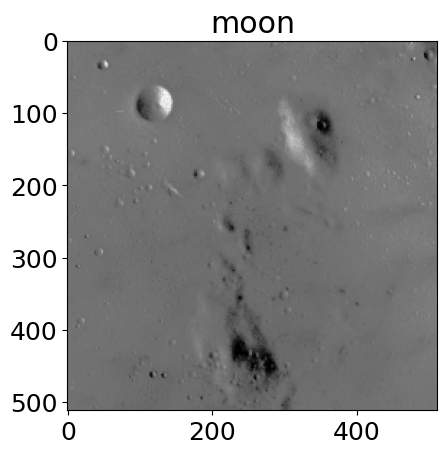

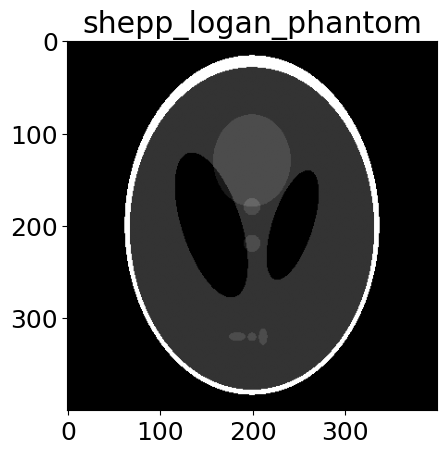

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import skimage as ski

matplotlib.rcParams['font.size'] = 18

images_names = [
    'moon',
    'shepp_logan_phantom',
]

images = []

for name in images_names:
    caller = getattr(ski.data, name)
    image = caller()
    plt.figure()
    plt.title(name)
    if image.ndim == 2:
        plt.imshow(image, cmap=plt.cm.gray)
    else:
        plt.imshow(image)
    images.append(image)
    plt.axis('off')

plt.show()

In [3]:
images[0].shape, images[1].shape

((512, 512), (400, 400))

## Histogram

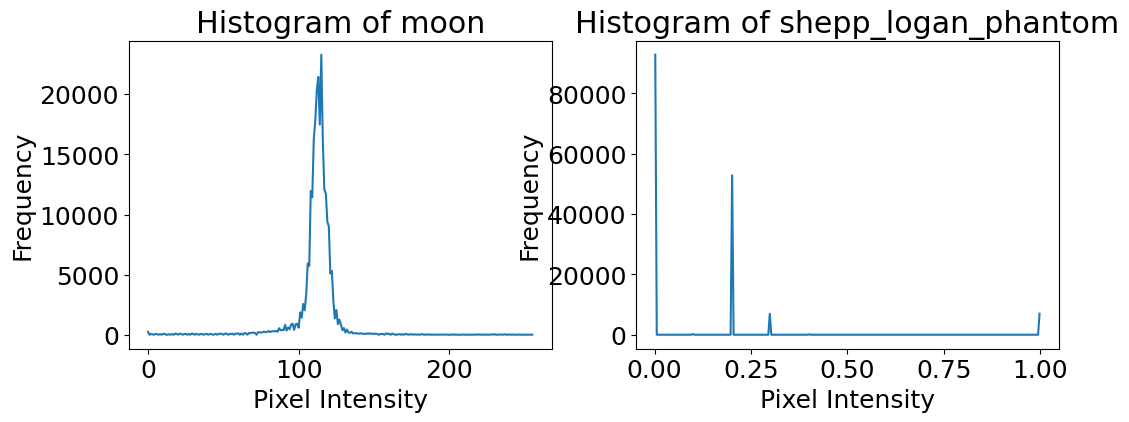

In [4]:
from skimage import exposure
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
for i, image in enumerate(images):
    # Calculate histogram
    hist, bins = exposure.histogram(image, nbins=256)

    # Plot histogram
    plt.subplot(1,2,i+1)
    plt.title(f'Histogram of {images_names[i]}')
    plt.plot(bins, hist)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.show()

## Match histograms

In [8]:
from skimage.util import img_as_ubyte # Import img_as_ubyte for type conversion
from skimage.exposure import match_histograms

# The 'moon' image (images[0]) is uint8. The 'shepp_logan_phantom' image (images[1]) is float64.
# match_histograms expects integer types for some internal operations.

# Convert the reference image (images[1]) to uint8, scaling its values from [0, 1] to [0, 255]
reference_image_uint8 = img_as_ubyte(images[1])

# Now apply histogram matching with compatible data types
matched_image = match_histograms(image=images[0], reference=reference_image_uint8, channel_axis=None)

print(f"Original image 0 dtype: {images[0].dtype}")
print(f"Original image 1 dtype: {images[1].dtype}")
print(f"Converted reference image dtype: {reference_image_uint8.dtype}")
print(f"Matched image dtype: {matched_image.dtype}")

Original image 0 dtype: uint8
Original image 1 dtype: float64
Converted reference image dtype: uint8
Matched image dtype: float64


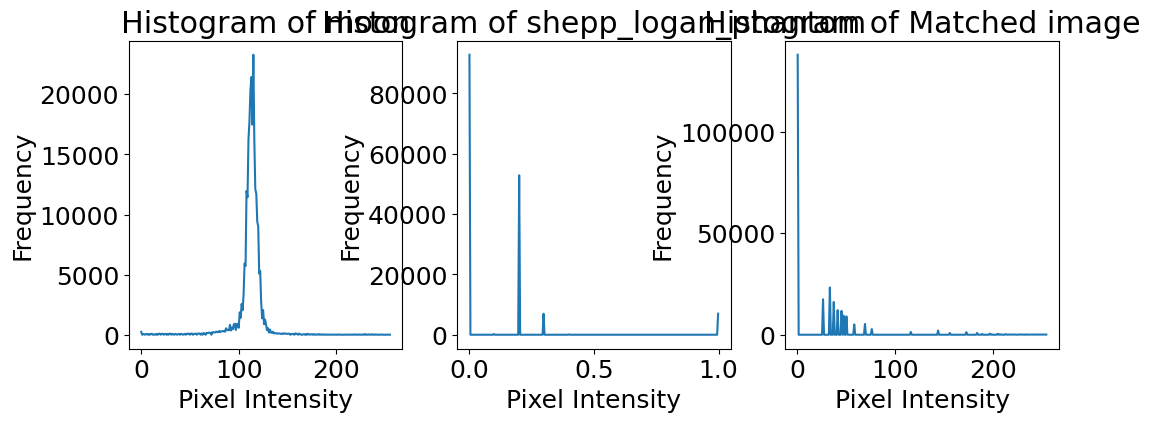

In [9]:
images.append(matched_image)
images_names.append('Matched image')

plt.figure(figsize=(12,4))
for i, image in enumerate(images):
    # Calculate histogram
    hist, bins = exposure.histogram(image, nbins=256)

    # Plot histogram
    plt.subplot(1,3,i+1)
    plt.title(f'Histogram of {images_names[i]}')
    plt.plot(bins, hist)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.show()

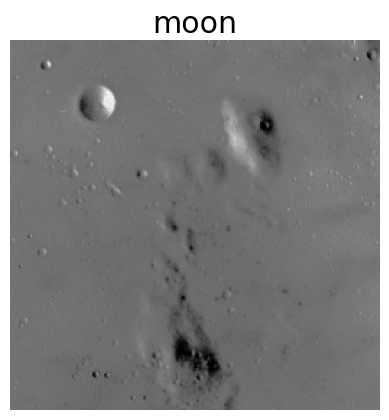

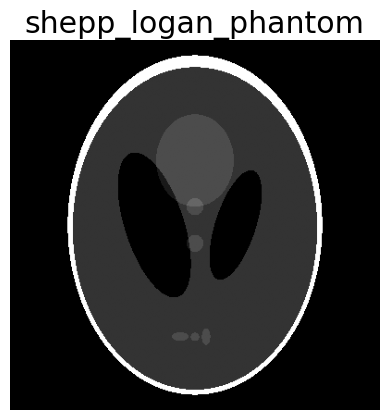

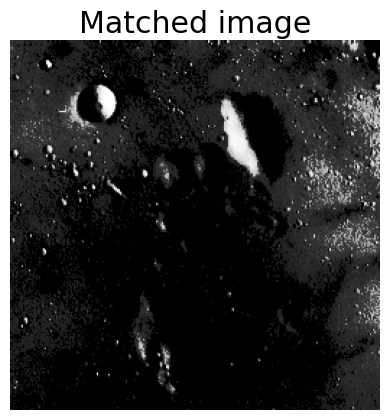

In [30]:
for i, name in enumerate(images_names):
    plt.figure()
    plt.title(name)
    if image.ndim == 2:
        plt.imshow(images[i], cmap=plt.cm.gray)
    else:
        plt.imshow(images[i])
    plt.axis('off')

plt.show()

## Ruído de Rice

Ao contrário do ruído gaussiano puro (que deixa o fundo cinza), o ruído de Rice mantém o fundo escuro com um aspecto "granulado" muito mais característico de uma Ressonância Magnética real.

A lógica para gerar o ruído de Rice sobre uma imagem limpa é:

$$I_{rice} = \sqrt{(I_{original} + N_{real})^2 + N_{imag}^2}$$

Onde $N_{real}$ e $N_{imag}$ são matrizes de ruído Gaussiano com média 0 e desvio padrão $\sigma$.

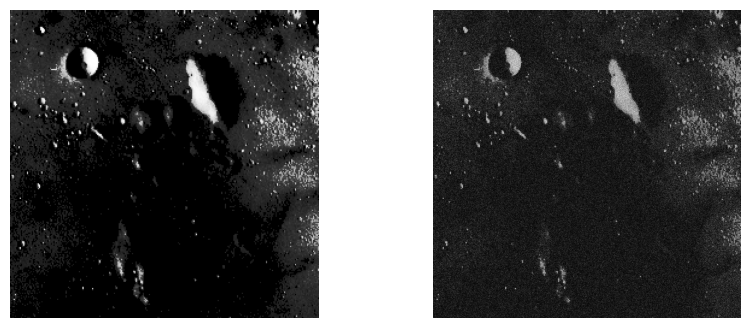

In [29]:
import numpy as np

def add_rice_noise(image, snr_target):
    """
    Adiciona ruído de Rice a uma imagem/volume com base em um SNR desejado.

    Parameters:
    -----------
    image : numpy.ndarray
        A imagem de entrada (pode ser 2D ou 3D), preferencialmente normalizada de 0 a 1 ou 0 a 255.
    snr_target : float
        A Razão Sinal-Ruído alvo. Valores menores (ex: 10-20) significam MAIS ruído.
        Valores maiores (ex: 50-100) significam imagem mais limpa.

    Returns:
    --------
    numpy.ndarray : Imagem corrompida com ruído de Rice.
    """
    # 1. Estimar a intensidade do sinal da imagem (usamos a média dos pixels brilhantes)
    # Ignoramos o fundo escuro (pixels próximos de 0) para não subestimar o sinal do vaso
    signal_intensity = np.mean(image[image > np.mean(image)])

    # 2. Calcular o sigma (desvio padrão do ruído) com base no SNR desejado
    # SNR = Sinal / Sigma  ->  Sigma = Sinal / SNR
    sigma = signal_intensity / snr_target

    # 3. Gerar as duas componentes independentes de ruído Gaussiano
    noise_real = np.random.normal(0, sigma, size=image.shape)
    noise_imag = np.random.normal(0, sigma, size=image.shape)

    # 4. Aplicar a transformação de Rice
    # Somamos o ruído real diretamente ao sinal e combinamos com o imaginário
    image_noisy = np.sqrt((image + noise_real)**2 + noise_imag**2)

    # Se sua imagem original era inteira (ex: uint8), garante que o retorno mantenha o tipo
    if image.dtype == np.uint8:
        image_noisy = np.clip(image_noisy, 0, 255).astype(np.uint8)

    return image_noisy

matched_image_noise = add_rice_noise(matched_image, snr_target=2) # snr_target=2, alto ruído, para poder ver na imagem...
                                                                  # snr_target=15, como abaixo, fica difícil de observar a olho nu, mas já tem ruído
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(matched_image, cmap=plt.cm.gray)
plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(matched_image_noise, cmap=plt.cm.gray)

plt.show()

## snr_target

Faça o teste visual em uma fatia isolada exibindo o "antes" e o "depois" para ver se com `snr_target = 15` não é muito ruído para aproximar as imagens... se for, aumente para `snr_target = 20` (menos ruído).

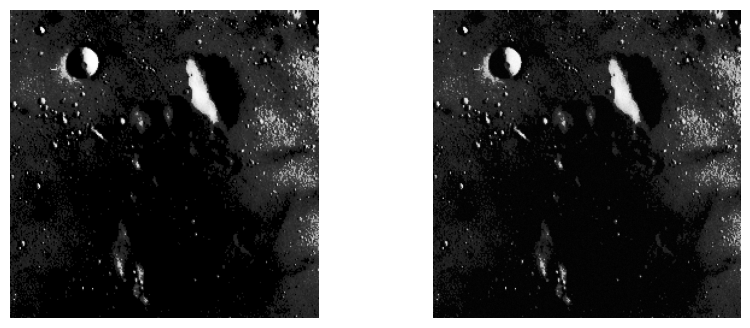

In [27]:
matched_image_noise = add_rice_noise(matched_image, snr_target=15)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(matched_image, cmap=plt.cm.gray)
plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(matched_image_noise, cmap=plt.cm.gray)

plt.show()

# No pipeline de data augumentation

Por exemplo, pode aplicar o ruído em 50% das imagens Siemens para aproximá-las de 1.5T (GE).

> **Lembrando novamente**: Isso não exclui variações de brilho, contraste e ruído gaussiano durante o treinamento no Data Augmentation. Isso é adicional para as imagens, 3T.

In [ ]:
%%script echo off
# No loop de treinamento

if fabricante == "Siemens Skyra" and np.random.rand() > 0.5: # ou outro valor

    # Aplica o ruído em 50% das imagens Siemens para aproximá-las de 1.5T
    imagem_treino = add_rice_noise(imagem_treino, snr_target=15)